In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


FruitinAmazon dataset is a collection of images specifically curated to represent various types of fruits (like Apples, Bananas, Oranges, etc.).

In [3]:
import zipfile, os

ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/AI_ML_Practice/Week5/FruitinAmazon.zip" # location of my zipfile

EXTRACT_DIR = "./fruitnamazon_dataset" # under current directory (./) create the new folder to store extracted dataset
os.makedirs(EXTRACT_DIR, exist_ok=True) # this is where it actually gets created.

# Unzip the file
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)
print(f"File '{os.path.basename(ZIP_PATH)}' unzipped to '{EXTRACT_DIR}'")

File 'FruitinAmazon.zip' unzipped to './fruitnamazon_dataset'


##Task 1: Data Understanding and Visualization:

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class.

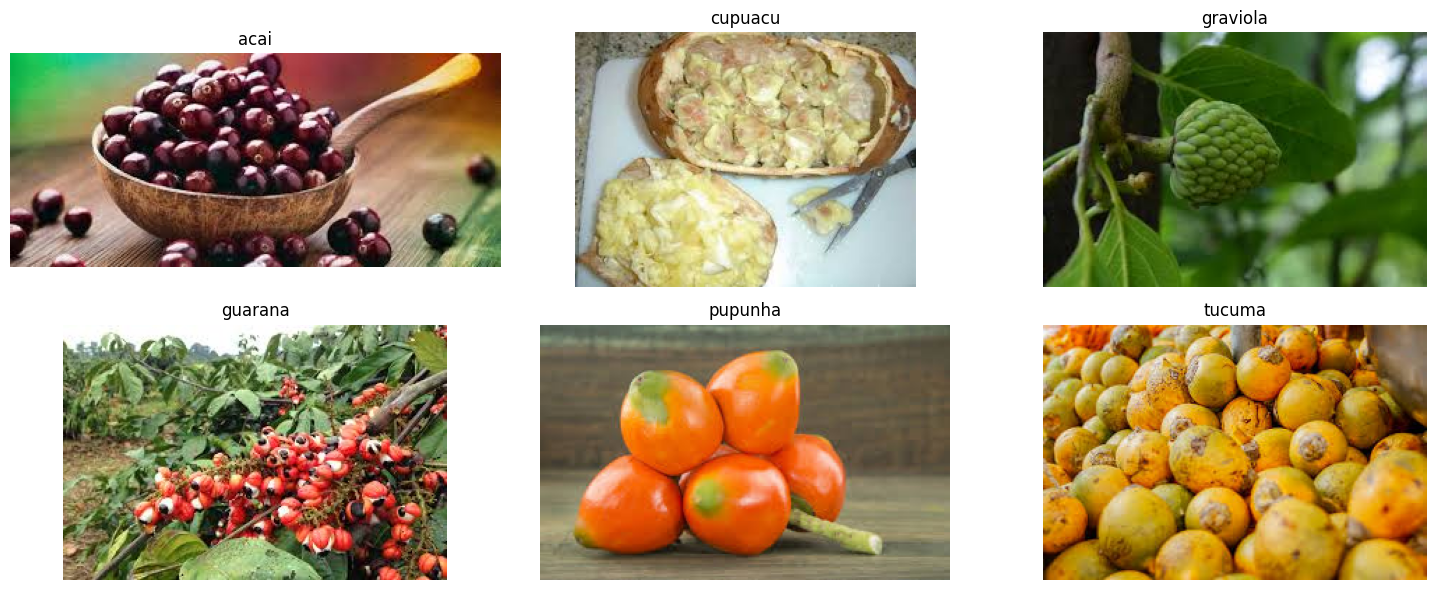

In [13]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# training data path
train_dir = "/content/fruitnamazon_dataset/FruitinAmazon/train"
test_dir = "/content/fruitnamazon_dataset/FruitinAmazon/test"

# finds list of folder and each folder is class, folder: apple, banana, orange etc.
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

# calculates how many columns we need to fit all classes into exactly 2 rows
num_classes = len(class_names)
cols = (num_classes + 1) // 2  # Calculate columns needed for 2 rows
plt.figure(figsize=(15, 6))

# Random Selection Loop and plots
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    random_img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_img_name)

    img = Image.open(img_path)

    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Check for Corrupted Image:

In [14]:

corrupted_images = []

# Iterate through each class subdirectory
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for filename in os.listdir(class_path):
        image_path = os.path.join(class_path, filename)

        try:
            # Attempt to load and verify the image
            with Image.open(image_path) as img:
                img.verify()
        except (IOError, SyntaxError):
            # If corrupted, remove and record
            print(f"Removed corrupted image: {image_path}")
            os.remove(image_path)
            corrupted_images.append(image_path)


if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"Cleaned up {len(corrupted_images)} images.")

No Corrupted Images Found.


##Task 2: Loading and Preprocessing Image Data in keras:

In [15]:
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation

#Pixel values are 0–255, dividing by 255 brings them to 0–1.
rescale = tf.keras.layers.Rescaling(1./255)

# 3. Create training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',     #tells label to use subfolder names
    label_mode='int', #Encode labels as integers — apple=0, banana=1, mango=2 etc. Required for sparse_categorical_crossentropy.
    image_size=(img_height, img_width),
    interpolation='nearest', #When resizing, fill new pixels by copying the nearest original pixel. Simple and fast.
    batch_size=batch_size,
    shuffle=True, #Randomise order every epoch so the model doesn't learn class order instead of patterns.
    validation_split=validation_split,
    subset='training', #This call gets the 80% training portion. The val_ds call below gets the other 20%
    seed=123 #guarantes the same 80/20 split every time, no image appears in both.
)

# 4. Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,              # Validation should not be shuffled
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# 5. Apply Normalization to both
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("\nDatasets are loaded and normalized!")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.

Datasets are loaded and normalized!


In [16]:
from tensorflow.keras import layers, models

#  lists everything inside the train folder
#  filters to folders only
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(class_names)

print(f"Building model for {num_classes} classes: {class_names}\n")

# Build the Sequential Model
model = models.Sequential([
    # --- Convolutional Architecture ---

    # Convolutional Layer 1
    # create 32 filters, producing 32 feature maps. Each filter learns a different pattern — edges, curves,
    # each filter is a 3×3 grid of learnable numbers sliding across the image.
    # move the filter one pixel at a time horizontally and vertically.
    # adds zeros around the border so output spatial size = input spatial size
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', activation='relu', input_shape=(128, 128, 3)),

    #window that slides across the feature map taking the maximum value from each 2×2 region.
    # jumps 2 pixels each time, so windows don't overlap. This is what halves the spatial size.
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # --- Fully Connected Network Architecture ---
    layers.Flatten(),

    # Hidden Layer 1 (64 neurons)
    layers.Dense(64, activation='relu'),

    # Hidden Layer 2 (128 neurons)
    layers.Dense(128, activation='relu'),

    # Output Layer
    # one neuron per fruit class.
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Building model for 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile and Train the Model

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


model.compile(
    optimizer='adam', #tells Keras how to update weights during backward propagation. Adam automatically adapts the learning rate η per weight
    loss='sparse_categorical_crossentropy', #  labels are integers
    metrics=['accuracy']
)


# ModelCheckpoint saves the best version based on validation loss
checkpoint = ModelCheckpoint(
    'best_fruit_model.h5',
    monitor='val_loss', # Watch validation loss, not training loss.
    save_best_only=True, #Only overwrite best_fruit_model.h5 when val_loss improves. Without this, every epoch overwrites the file
    verbose=1 # Print a message when the model is saved
)

# EarlyStopping stops training if val_loss doesn't improve for 10 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stop]
)



Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.1447 - loss: 1.8856
Epoch 1: val_loss improved from None to 2.44335, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 962ms/step - accuracy: 0.1528 - loss: 1.9390 - val_accuracy: 0.0000e+00 - val_loss: 2.4433
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.2141 - loss: 1.7350
Epoch 2: val_loss improved from 2.44335 to 1.86990, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 455ms/step - accuracy: 0.2361 - loss: 1.7336 - val_accuracy: 0.0556 - val_loss: 1.8699
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.5399 - loss: 1.6236
Epoch 3: val_loss improved from 1.86990 to 1.72979, saving model to best_fruit_model.h5



Epoch 3: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 445ms/step - accuracy: 0.5417 - loss: 1.5903 - val_accuracy: 0.0556 - val_loss: 1.7298
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.4190 - loss: 1.4378
Epoch 4: val_loss improved from 1.72979 to 1.49741, saving model to best_fruit_model.h5



Epoch 4: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 457ms/step - accuracy: 0.4444 - loss: 1.4057 - val_accuracy: 0.3889 - val_loss: 1.4974
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.5289 - loss: 1.1537
Epoch 5: val_loss improved from 1.49741 to 1.28394, saving model to best_fruit_model.h5


...


Epoch 7: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 467ms/step - accuracy: 0.7778 - loss: 0.7612 - val_accuracy: 0.8889 - val_loss: 0.9440
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.9103 - loss: 0.5793
Epoch 8: val_loss improved from 0.94404 to 0.70969, saving model to best_fruit_model.h5



Epoch 8: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 485ms/step - accuracy: 0.9028 - loss: 0.5838 - val_accuracy: 0.8889 - val_loss: 0.7097
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.9462 - loss: 0.3380
Epoch 9: val_loss improved from 0.70969 to 0.50989, saving model to best_fruit_model.h5



Epoch 9: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 863ms/step - accuracy: 0.9167 - loss: 0.3793 - val_accuracy: 0.9444 - val_loss: 0.5099
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.9803 - loss: 0.2185
Epoch 10: val_loss did not improve from 0.50989
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 401ms/step - accuracy: 0.9722 - loss: 0.2234 - val_accuracy: 0.6111 - val_loss: 0.8937
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9294 - loss: 0.2436
Epoch 11: val_loss did not improve from 0.50989
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 410ms/step - accuracy: 0.9444 - loss: 0.2208 - val_accuracy: 0.8889 - val_loss: 0.6930
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9705 - loss: 0.1357
Epoch 12: val_loss improved from 0.50989 to 0.48452, saving model to best_fruit_model.h5



Epoch 12: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 466ms/step - accuracy: 0.9583 - loss: 0.1469 - val_accuracy: 0.8889 - val_loss: 0.4845
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 1.0000 - loss: 0.0855
Epoch 13: val_loss improved from 0.48452 to 0.44189, saving model to best_fruit_model.h5



Epoch 13: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 457ms/step - accuracy: 1.0000 - loss: 0.0811 - val_accuracy: 0.8889 - val_loss: 0.4419
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.9803 - loss: 0.0578
Epoch 14: val_loss did not improve from 0.44189
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 433ms/step - accuracy: 0.9722 - loss: 0.0702 - val_accuracy: 0.7778 - val_loss: 0.5110
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 1.0000 - loss: 0.0341
Epoch 15: val_loss did not improve from 0.44189
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 394ms/step - accuracy: 1.0000 - loss: 0.0381 - val_accuracy: 0.8333 - val_loss: 0.5096
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.9699 - loss: 0.0598
Epoch 16: val_loss did not improve from 0.44189
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 633ms/step - accuracy: 0.9722 - loss: 0.0560 - val_accuracy: 0.8889 - val_loss: 0.5452
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 1.0000 - loss: 0.0

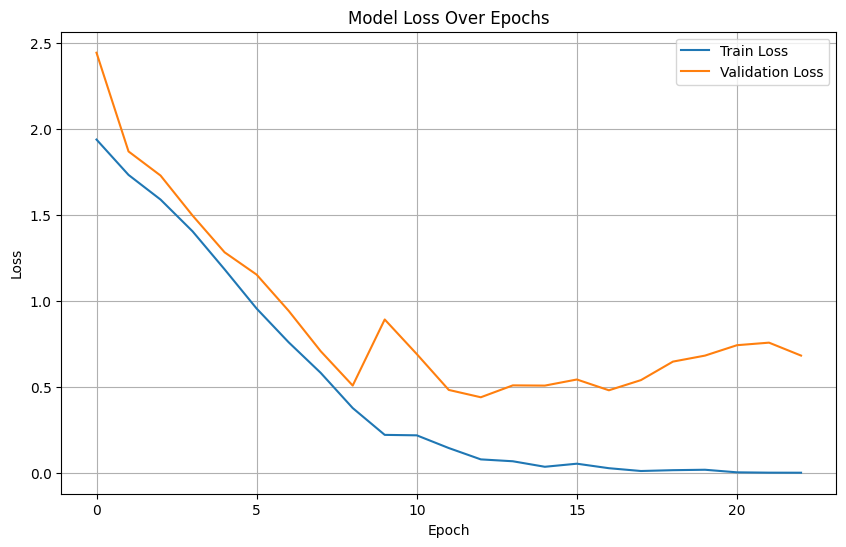

In [21]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

Task 5: Evaluate the Model

In [18]:
# --- Task 5: Evaluate the Model ---
print("\n--- Final Evaluation on Validation Set ---")
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")


--- Final Evaluation on Validation Set ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.8889 - loss: 0.4419
Loss: 0.4419, Accuracy: 0.8889


Task 6: Save and Load the Model

In [19]:
from tensorflow.keras.models import load_model

# 1. Save the model explicitly
model.save('final_fruit_model.h5')
print("Model saved successfully as 'final_fruit_model.h5'")

# 2. Load the saved model (using the 'best' one saved by our checkpoint)
loaded_model = load_model('best_fruit_model.h5')
print("Best version of the model reloaded successfully!")

# 3. Re-evaluate to prove it works
re_loss, re_acc = loaded_model.evaluate(val_ds)
print(f"Reloaded Model Accuracy: {re_acc*100:.2f}%")

Model saved successfully as 'final_fruit_model.h5'
Best version of the model reloaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step - accuracy: 0.8889 - loss: 0.4419
Reloaded Model Accuracy: 88.89%


Task 7: Predictions and Classification Report

In [20]:
from sklearn.metrics import classification_report
import numpy as np
import tensorflow as tf

# 1. Load test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=32,
    label_mode='int',
    shuffle=False
)

# 2. Normalise test data
rescale = tf.keras.layers.Rescaling(1./255)
test_ds_scaled = test_ds.map(lambda x, y: (rescale(x), y))

# 3. Extract ground truth and predictions
y_true = []
y_pred_probs = []

print("Generating predictions on test set...")
for images, labels in test_ds_scaled:
    preds = loaded_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Get class names from test folder
class_names = sorted([
    d for d in os.listdir(test_dir)
    if os.path.isdir(os.path.join(test_dir, d))
])

# 5. Generate report for all 6 classes
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print("\n--- FINAL CLASSIFICATION REPORT (TEST SET) ---")
print(report)

Found 30 files belonging to 6 classes.
Generating predictions on test set...

--- FINAL CLASSIFICATION REPORT (TEST SET) ---
              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       1.00      0.40      0.57         5
    graviola       0.45      1.00      0.62         5
     guarana       1.00      0.80      0.89         5
     pupunha       1.00      0.80      0.89         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.70        30
   macro avg       0.80      0.70      0.70        30
weighted avg       0.80      0.70      0.70        30

